In [312]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA, QuadraticDiscriminantAnalysis as QDA
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler


train = pd.read_csv("train.csv")

### Stating the Question - What factors were predictors of suvival on the Titanic? Can we create a model from these to predict if a passanger survived?

### Exploring and Cleaning the Dataset

In [313]:


train.head()
train.columns

# Pclass - Ticekt Class 1st,2nd,3rd
# SibSp - # of siblings/spuses aboard
# Parch - # of parents/children aboard

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [314]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Columns with Null values - Age,Cabin,Embarked

Cabin - convert to T/F has a cabin recorded or not

Age - Mean age grouped by class

Embarked - fill with mode

In [315]:
# Fill missing Ages
train.groupby("Pclass")["Age"].mean()


Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

In [316]:
train['Age']=train.Age.fillna(train.groupby('Pclass')['Age'].transform('mean'))

In [317]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [318]:
# Fill Embarked
#train.Embarked.mode()
train['Embarked']=train.Embarked.fillna(train.Embarked.mode()[0])
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [319]:
# Cleaning Up Cabin

train['Cabin']=train.Cabin.notna()
train['Cabin']=train['Cabin'].astype(int)
train['Cabin'].value_counts()

Cabin
0    687
1    204
Name: count, dtype: int64

In [320]:
train.info()
train.head

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    int64  
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(6), object(4)
memory usage: 83.7+ KB


<bound method NDFrame.head of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex       Age  \
0                              Braund, Mr. Owen Harris    male  22.00000   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.00000   
2                               Heikkinen, Miss. Laina  female  26.00000   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.00000   
4                             Allen, Mr. William Henry    male  35.00000   
..                                                 ...   

### Exploratory Data Analysis

In [321]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.292875,0.523008,0.381594,32.204208,0.228956
std,257.353842,0.486592,0.836071,13.210527,1.102743,0.806057,49.693429,0.420397
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,0.000000
50%,446.000000,0.000000,3.000000,26.000000,0.000000,0.000000,14.454200,0.000000
75%,668.500000,1.000000,3.000000,37.000000,1.000000,0.000000,31.000000,0.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000


#### 'PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
####       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'


#### Columns I know are not important: Name,Ticket,Passenger ID

#### Columns to explore: Pclass (categorical), Sex(categorical), Age(continuous), SibSp(categorical),Parch(categorical), Fare(continuous),Cabin(categorical),Embarked(categorical)

Text(0.5, 1.0, 'Survival Rate by Class')

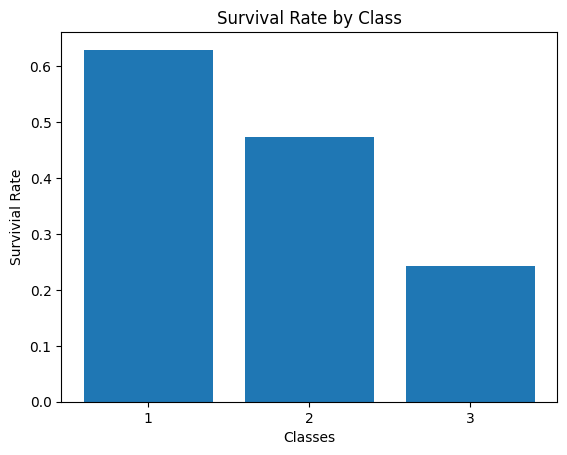

In [322]:
# Pclass
# Need Survival Rate Per Class
survivalrate=train.groupby('Pclass')['Survived'].mean()


vals=survivalrate.values
labels=survivalrate.index.astype(str)
fig,ax=plt.subplots()
ax.bar(labels,vals)
ax.set_xlabel('Classes')
ax.set_ylabel('Survivial Rate')
ax.set_title("Survival Rate by Class")

# As expected there is a clear pattern


Text(0.5, 1.0, 'Survival Rate by Sex')

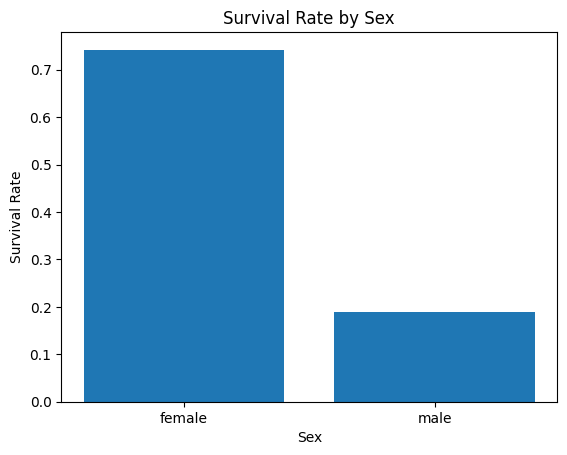

In [323]:
# Sex

# Survival Rate by Sex
survivalratesex=train.groupby('Sex')['Survived'].mean()
#survivalratesex
valsex=survivalratesex.values
labelsex=survivalratesex.index
fig,ax=plt.subplots()
ax.bar(labelsex,valsex)
ax.set_xlabel("Sex")
ax.set_ylabel("Survival Rate")
ax.set_title("Survival Rate by Sex")

# Clear patten

[Text(1, 0, 'Survived'), Text(2, 0, 'Did Not Survive')]

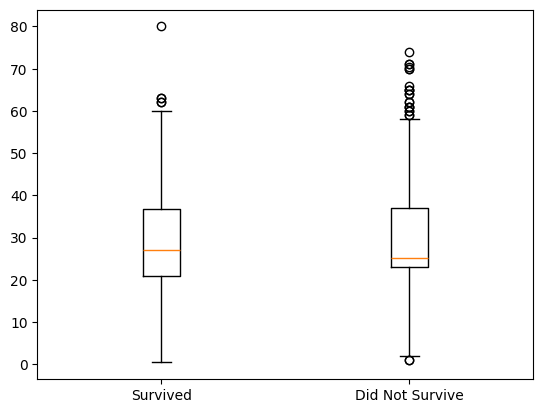

In [324]:
# Age

# Split into Survived and Didn't
survived=train[train['Survived']==1]
nosurvived=train[train['Survived']==0]

# Get only Age column
agesurvived=survived['Age']
agenosurvived=nosurvived['Age']

fig,ax=plt.subplots()
ax.boxplot([agesurvived,agenosurvived])
ax.set_xticklabels(['Survived','Did Not Survive'])

# less clear pattern - .describ() shows very similar measures of location

In [325]:
agesurvived.describe()
agenosurvived.describe()

count    549.000000
mean      29.819165
std       12.715344
min        1.000000
25%       23.000000
50%       25.140620
75%       37.000000
max       74.000000
Name: Age, dtype: float64

Text(0, 0.5, 'Survival Rate')

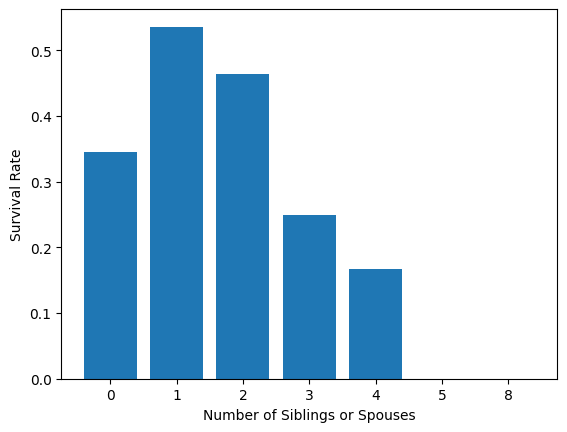

In [326]:
#SibSp

# Survival Rate by number of Siblings/Spouse:
survivalratesibsp=train.groupby('SibSp')['Survived'].mean()
#survivalratesibsp
valssib=survivalratesibsp.values
labelssib=survivalratesibsp.index.astype(str)

fig,ax=plt.subplots()
ax.bar(labelssib,valssib)
ax.set_xlabel("Number of Siblings or Spouses")
ax.set_ylabel("Survival Rate")

# Some pattern, nonlinear, kind of weird

Text(0, 0.5, 'Survival Rate')

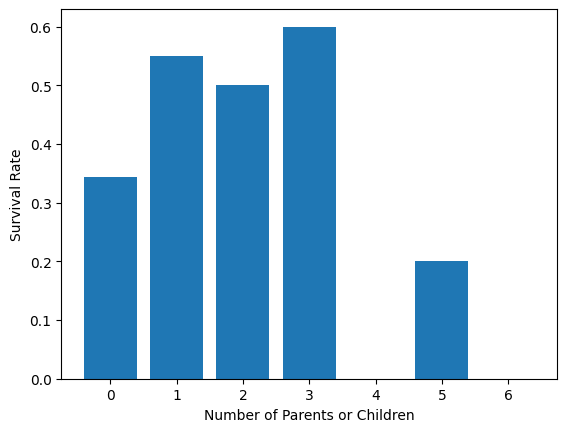

In [327]:
# Parch

# Survival Rate by Number of Parent/Children

survivalrateparch=train.groupby('Parch')['Survived'].mean()

valsparch=survivalrateparch.values
labelsparch=survivalrateparch.index.astype(str)

fig,ax=plt.subplots()
ax.bar(labelsparch,valsparch)
ax.set_xlabel("Number of Parents or Children")
ax.set_ylabel("Survival Rate")

# same as sibsp weird nonlinear

[Text(1, 0, 'Survived'), Text(2, 0, 'Did Not Survive')]

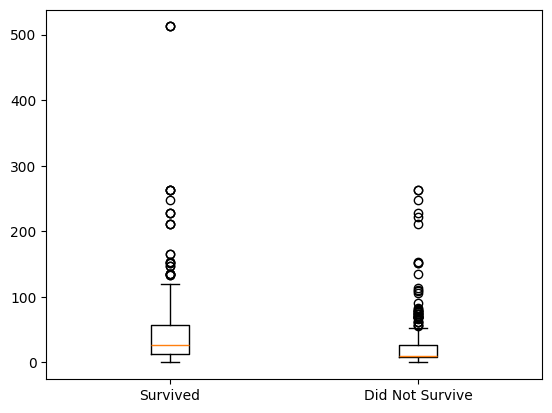

In [328]:
# Fare

# Split into survived versus not before 
# Filter to Fare
faresurvived=survived['Fare']
farenosurvived=nosurvived['Fare']

fig,ax=plt.subplots()
ax.boxplot([faresurvived,farenosurvived])
ax.set_xticklabels(['Survived','Did Not Survive'])

# Mean is higher for survived - as expected richer survived 
# Survived has larger std dev because while more rich survived, some poor did as well
# assuming rich = higher fare
# Possible correlation with Pclass, I am using both as a measure of status


In [329]:
faresurvived.describe()

count    342.000000
mean      48.395408
std       66.596998
min        0.000000
25%       12.475000
50%       26.000000
75%       57.000000
max      512.329200
Name: Fare, dtype: float64

In [330]:
farenosurvived.describe()

count    549.000000
mean      22.117887
std       31.388207
min        0.000000
25%        7.854200
50%       10.500000
75%       26.000000
max      263.000000
Name: Fare, dtype: float64

Text(0, 0.5, 'Survival Rate')

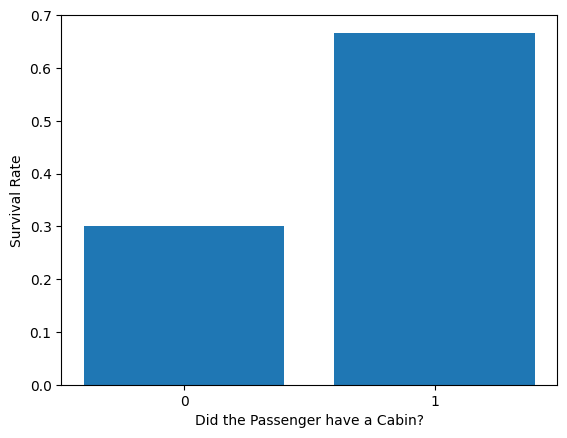

In [331]:
# Cabin

# Survival Rate
survivalratecabin=train.groupby('Cabin')['Survived'].mean()

valscabin=survivalratecabin.values
labelscabin=survivalratecabin.index.astype(str)

fig,ax=plt.subplots()
ax.bar(labelscabin,valscabin)
ax.set_xlabel('Did the Passenger have a Cabin?')
ax.set_ylabel("Survival Rate")

# As expected Cabin True = much higher survival rate


Text(0, 0.5, 'Survival Rate')

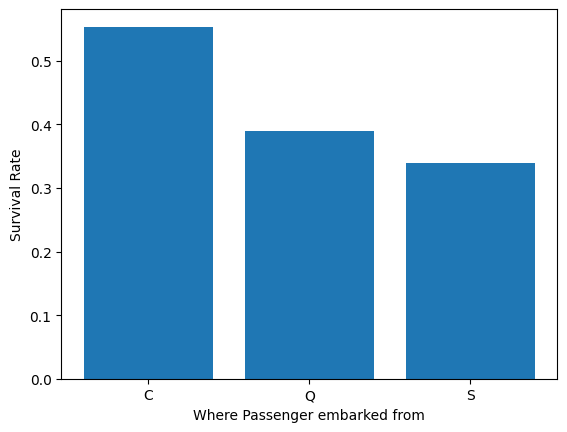

In [332]:
# Embarked

# Survival Rate
survivalrateembarked=train.groupby('Embarked')['Survived'].mean()

valsembarked=survivalrateembarked.values
labelsembarked=survivalrateembarked.index.astype(str)

fig,ax=plt.subplots()
ax.bar(labelsembarked,valsembarked)
ax.set_xlabel('Where Passenger embarked from')
ax.set_ylabel("Survival Rate")


In [333]:
# Correlation

correlation=train[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare','Cabin']].corr()


# Correlated Predictor: Pclass/Fare Pclass/Cabin 

<Axes: >

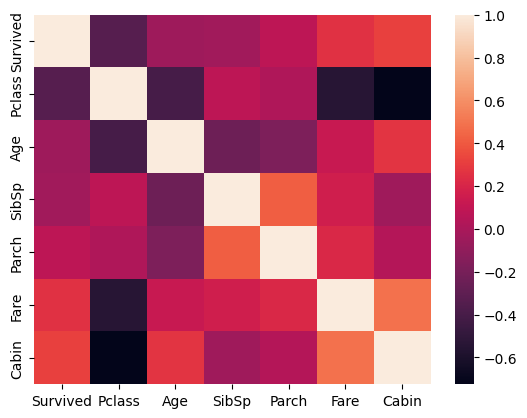

In [334]:
# Correlation HeatMap

sns.heatmap(correlation)

### EDA Takeaways

#### Pclass - Bar Chart shows pattern in survival rate across classes - 1>2>3

#### Sex - Women had much higher survival rate

#### Age - Seems to have very similar mesaures of location, maybe not a useful predictor

#### SibSp - There does appear to be some pattern but it is nonlinear 

#### ParCh - Same as Sib Sp

#### - Note ParCh and SibSp might be worth combining into "Family" or "Dependents"

#### Fare - Measures of location are different between survived and didn't

#### - Note Fare is a measure of wealth or status similar to Pclass

#### Cabin - Clear Pattern those with a cabin had much higher survival rate

#### - Note Cabin is also a measure of wealth/status

#### Embarked - leaving from C had a noticeable increase in survival rate. Q had more than S but similar

#### Correlation - Fare,Pclass,Cabin Correlated

#### - Sex and Embarked not included in correlation explore more?


### Feature Engineering


In [335]:
# Creating Dependents Predictor
train['Dependents']=train['SibSp']+train['Parch']

train.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Dependents
886,887,0,2,"Montvila, Rev. Juozas",male,27.00000,0,0,211536,13.00,0,S,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.00000,0,0,112053,30.00,1,S,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,25.14062,1,2,W./C. 6607,23.45,0,S,3
889,890,1,1,"Behr, Mr. Karl Howell",male,26.00000,0,0,111369,30.00,1,C,0
890,891,0,3,"Dooley, Mr. Patrick",male,32.00000,0,0,370376,7.75,0,Q,0


In [336]:
# Embarked

# Since Bar chart seemed to show Q and S were similar in survival rate, T/F (1/0) if Embarked from C or not
train['Embarked']=train['Embarked'].replace({'C':1,'Q':0,"S":0})
train.head()
train['Embarked'].unique()



C:\Users\ssark\AppData\Local\Temp\ipykernel_41592\3421959136.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train['Embarked']=train['Embarked'].replace({'C':1,'Q':0,"S":0})


array([0, 1])

In [337]:
# Sex

# Make sex 0/1

train['Sex']=train['Sex'].replace({'male':0,'female':1})
train.head()

C:\Users\ssark\AppData\Local\Temp\ipykernel_41592\3910512656.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train['Sex']=train['Sex'].replace({'male':0,'female':1})


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Dependents
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1,1,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,1,0,1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0,0,0


### Feature Selection

#### Methodology: Backward Selection - Fit Logistic Regression for with all predictors then drop based on PValues.
#### All predictors will exclude Name, Ticket, Passenger ID which were determined to not be important prior to EDA and just record keeping

#### Then fit Logistic, KNN, LDA, QDA, and Naive Bayes with those predictors

In [338]:
# Fitting Logistic with all predictors
allvars=train.columns.drop(['Name','Ticket','PassengerId','Survived'])
design=sm.add_constant(train[allvars])
#design.dtypes
x=design
y=train['Survived']==1
glm=sm.GLM(y,x,family=sm.families.Binomial())
results=glm.fit()
results.summary()



<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               Survived   No. Observations:                  891
Model:                            GLM   Df Residuals:                      882
Model Family:                Binomial   Df Model:                            8
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -388.55
Date:                Sat, 06 Jun 2026   Deviance:                       777.10
Time:                        15:16:40   Pearson chi2:                     918.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3685
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.7896      0.585      3.059      0.002       0.643       2.936
Pclass        -0.9375      0.174     -5.401      0.000      -1.278      -0.597
Sex            2.7656      0.201     13.775      0.000       2.372       3.159
Age           -0.0437      0.008     -5.295      0.000      -0.060      -0.028
SibSp         -0.1956      0.093     -2.100      0.036      -0.378      -0.013
Parch          0.0412      0.096      0.427      0.669      -0.148       0.230
Fare           0.0011      0.002      0.479      0.632      -0.003       0.006
Cabin          0.6864      0.296      2.321      0.020       0.107       1.266
Embarked       0.3616      0.237      1.525      0.127      -0.103       0.826
Dependents    -0.1544      0.047     -3.319      0.001      -0.246      -0.063
==============================================================================
"""

### Drop Parch Fare Embarked based on P-Value
### Drop SibSp becaue redundant due to Dependents 
### Final Predictors: Pclass, Sex, Age, Cabin, Dependents

### Modeling

In [339]:
# Logistic Regression
# Setting up Model Variables
predictors=train[['Pclass','Sex','Age','Cabin','Dependents']]
design=sm.add_constant(predictors)
x=design
y=train['Survived']==1
# Train Test Split
X_trainlog,X_testlog,Y_trainlog,Y_testlog=train_test_split(x,y,random_state=1,test_size=.2)
# Fitting
glm_train=sm.GLM(Y_trainlog,X_trainlog,family=sm.families.Binomial())
results=glm_train.fit()
# Predicting and Evaluating
probs=results.predict(exog=X_testlog)
labels=np.array([0]*len(Y_testlog))
labels[probs>.5]=1
pd.DataFrame(confusion_matrix(Y_testlog, labels), 
             index=['Actual 0', 'Actual 1'], 
             columns=['Predicted 0', 'Predicted 1'])

accuracy=np.mean(labels==Y_testlog)
error=1-accuracy
print(f"Error Rate: {error:.4f}")

Error Rate: 0.1844


In [340]:
# Linear Discriminant Analysis
x=predictors
X_train,X_test,Y_train,Y_test=train_test_split(x,y,random_state=1,test_size=.2)
# Fitting LDA
lda=LDA(store_covariance=True)
lda.fit(X_train,Y_train)
labelslda=lda.predict(X_test)
pd.DataFrame(confusion_matrix(Y_test, labelslda), 
             index=['Actual 0', 'Actual 1'], 
             columns=['Predicted 0', 'Predicted 1'])
accuracylda=np.mean(labelslda==Y_test)
errorlda=1-accuracylda
print(f"Error Rate: {errorlda:.4f}")

Error Rate: 0.1844


In [341]:
# Quadratic Discriminant Analysis
# Fitting QDA
qda=QDA(store_covariance=True)
qda.fit(X_train,Y_train)
labelsqda=qda.predict(X_test)
pd.DataFrame(confusion_matrix(Y_test, labelsqda), 
             index=['Actual 0', 'Actual 1'], 
             columns=['Predicted 0', 'Predicted 1'])
accuracyqda=np.mean(labelsqda==Y_test)
errorqda=1-accuracyqda
print(f"Error Rate: {errorqda:.4f}")

Error Rate: 0.2179


In [342]:
# Naive Bayes
NB=GaussianNB()
NB.fit(X_train,Y_train)
nb_labels=NB.predict(X_test)
pd.DataFrame(confusion_matrix(Y_test,nb_labels),
             index=['Acutal 0','Actual 1'],
             columns=['Predicted 0','Predicted 1'])
accuracynb=np.mean(nb_labels==Y_test)
errornb=1-accuracynb
print(f"Error Rate:{errornb:.4f}")

Error Rate:0.2291


In [347]:
# K Nearest Neighbors
scaler=StandardScaler(with_mean=True,with_std=True,copy=True)
scaler.fit(X_train)
x_trainknn=scaler.transform(X_train)
X_testknn=scaler.transform(X_test)

for k in range(1,20):
    knn=KNeighborsClassifier(n_neighbors=k)
    knn_pred=knn.fit(x_trainknn,Y_train).predict(X_testknn)
    print(f"K:{k}:error:{1-np.mean(knn_pred==Y_test):.1%}")



K:1:error:29.6%
K:2:error:26.8%
K:3:error:23.5%
K:4:error:22.9%
K:5:error:24.0%
K:6:error:25.1%
K:7:error:26.3%
K:8:error:24.6%
K:9:error:25.1%
K:10:error:25.1%
K:11:error:22.9%
K:12:error:24.0%
K:13:error:22.3%
K:14:error:22.9%
K:15:error:23.5%
K:16:error:22.9%
K:17:error:23.5%
K:18:error:23.5%
K:19:error:22.3%


### Best Model in Terms of Error Rate were Linear Disciminant Analysis and Logistic Regression

### Plan is to submit both and see which performs better since they had identical error rates

### Final Submission Work


In [349]:
test=pd.read_csv("test.csv")
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [351]:
# Clean Test
test['Age']=test.Age.fillna(test.groupby('Pclass')['Age'].transform('mean'))
test['Cabin']=test.Cabin.notna()
test['Cabin']=test['Cabin'].astype(int)

# Features
test['Dependents']=test['SibSp']+test['Parch']
test['Sex']=test['Sex'].replace({'male':0,'female':1})

C:\Users\ssark\AppData\Local\Temp\ipykernel_41592\2898978244.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test['Sex']=test['Sex'].replace({'male':0,'female':1})


In [354]:
# Logistic Regression Training
predicting=test[['Pclass', 'Sex', 'Age', 'Cabin', 'Dependents']]
predictinglog = sm.add_constant(predicting)
design=sm.add_constant(predictors)
x=design
y=train['Survived']==1
glm=sm.GLM(y,x,family=sm.families.Binomial())
results=glm.fit()
#Predicting
probs=results.predict(exog=predictinglog)
labels=np.array([0]*len(predictinglog))
labels[probs>.5]=1

predictions=pd.DataFrame({"PassengerId":test['PassengerId'],"Survived":labels})
predictions.to_csv("logistic_submission.csv", index=False)


In [357]:
# LDA Training
xlda=predictors
lda=LDA(store_covariance=True)
lda.fit(xlda,y)
# Predicting
lda_pred=lda.predict(predicting)
lda_pred = lda_pred.astype(int)
predictionslda=pd.DataFrame({"PassengerId":test['PassengerId'],"Survived":lda_pred})
predictionslda.to_csv("lda_submission1.csv",index=False)
